In [74]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [76]:
def load_images(data_path, label):
    images = []
    labels = []
    for file_name in os.listdir(data_path):
        if file_name.endswith(".png") or file_name.endswith(".jpg"):
            img_path = os.path.join(data_path, file_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                images.append(img)
                labels.append(label)
    return images, labels

In [78]:
original_path = "Downloads/FDS/signatures/full_org"  # Update this path to the actual path of original signatures
forged_path = "Downloads/FDS/signatures/full_forg"

In [80]:
original_images, original_labels = load_images(original_path, label=1)  # Label 1 for original
forged_images, forged_labels = load_images(forged_path, label=0)

In [81]:
all_images = original_images + forged_images
all_labels = original_labels + forged_labels

In [82]:
def calculate_envelopes(img):
    upper = np.max(img, axis=0)  # Max value along columns (or rows depending on your use)
    lower = np.min(img, axis=0)  # Min value along columns (or rows depending on your use)
    return upper, lower

In [88]:
def extract_statistical_features(images):
    features = []
    for img in images:
        # Calculate upper and lower envelopes
        upper, lower = calculate_envelopes(img)

        # Ensure envelopes are of the same length
        min_len = min(len(upper), len(lower))  # No extra indentation here
        upper = upper[:min_len]
        lower = lower[:min_len]

        # Combine upper and lower envelopes
        envelopes = np.concatenate([upper, lower])

        # Extract statistical features
        mean = np.mean(envelopes)
        std = np.std(envelopes)
        var = np.var(envelopes)
        skewness = np.mean((envelopes - mean)**3) / (std**3 if std > 0 else 1)
        kurtosis = np.mean((envelopes - mean)**4) / (std**4 if std > 0 else 1) - 3

        # Add features as a vector
        features.append([mean, std, var, skewness, kurtosis])

    return np.array(features)
    


In [90]:
# Extract features from all images
features = extract_statistical_features(all_images)

# Ensure the features are not empty
print(features.shape)

# Now you can use features in train_test_split
X_train, X_test, y_train, y_test = train_test_split(features, all_labels, test_size=0.3, random_state=42)

# Check if train_test_split has worked and X_train is defined
print(X_train.shape)  # Should show the shape of your training features

# Proceed with scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply PCA for dimensionality reduction
pca = PCA(n_components=0.95)  # Keep 95% of variance
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


(2640, 5)
(1848, 5)


In [92]:
param_grid = {'C': [1, 10, 100], 'gamma': [0.001, 0.01, 0.1], 'kernel': ['rbf', 'linear']}
grid_search = GridSearchCV(SVC(class_weight='balanced'), param_grid, cv=5)
grid_search.fit(X_train_pca, y_train)
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_pca)

In [33]:
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.64      0.69       398
           1       0.69      0.79      0.73       394

    accuracy                           0.71       792
   macro avg       0.72      0.72      0.71       792
weighted avg       0.72      0.71      0.71       792

Confusion Matrix:
 [[256 142]
 [ 84 310]]


Text(120.72222222222221, 0.5, 'True')

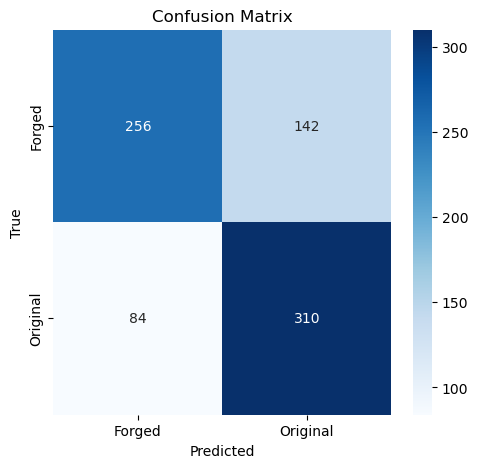

In [36]:
report_dict = classification_report(y_test, y_pred, output_dict=True)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Forged", "Original"], yticklabels=["Forged", "Original"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

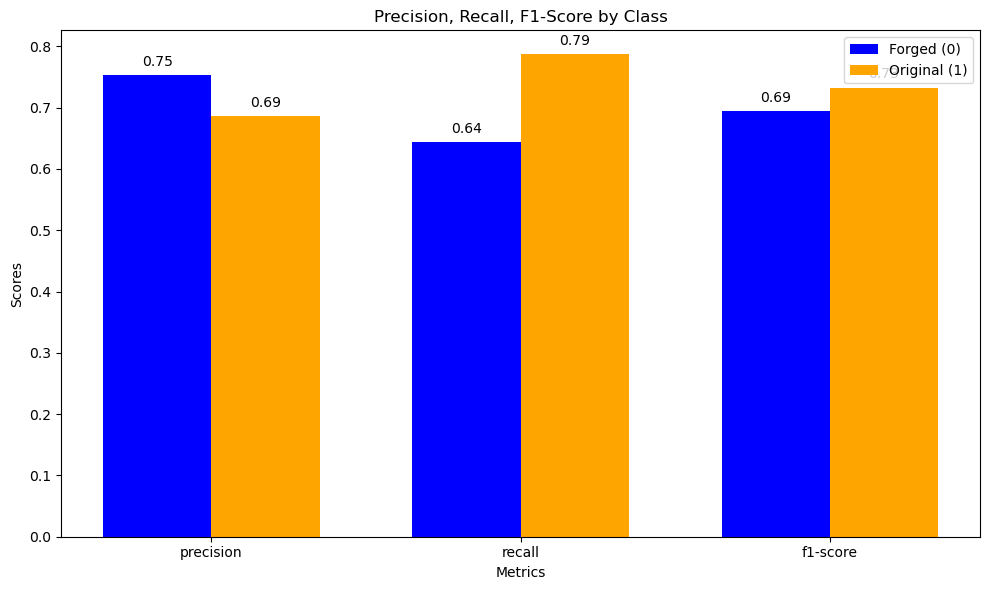

In [40]:
metrics = ['precision', 'recall', 'f1-score']
metric_values_class_0 = [report_dict['0'][metric] for metric in metrics]
metric_values_class_1 = [report_dict['1'][metric] for metric in metrics]
x = np.arange(len(metrics))  # Positions of the metrics
width = 0.35  
fig, ax = plt.subplots(figsize=(10, 6))
bars_class_0 = ax.bar(x - width/2, metric_values_class_0, width, label='Forged (0)', color='blue')
bars_class_1 = ax.bar(x + width/2, metric_values_class_1, width, label='Original (1)', color='orange')
ax.set_xlabel('Metrics')
ax.set_ylabel('Scores')
ax.set_title('Precision, Recall, F1-Score by Class')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
def add_labels(bars):
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 2), ha='center', va='bottom')
add_labels(bars_class_0)
add_labels(bars_class_1)
plt.tight_layout()
plt.show()

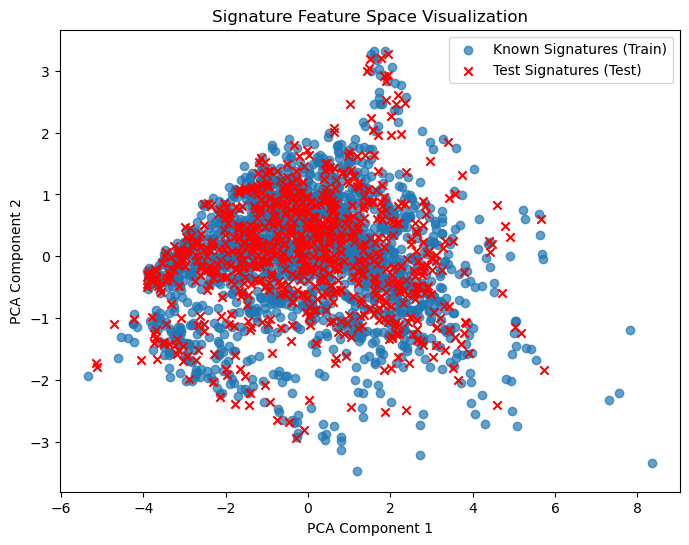

In [42]:
known_features = X_train_pca
test_features = X_test_pca
plt.figure(figsize=(8, 6))
plt.scatter(known_features[:, 0], known_features[:, 1], label='Known Signatures (Train)', alpha=0.7)
plt.scatter(test_features[:, 0], test_features[:, 1], label='Test Signatures (Test)', color='red', marker='x')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Signature Feature Space Visualization')
plt.legend()
plt.show()

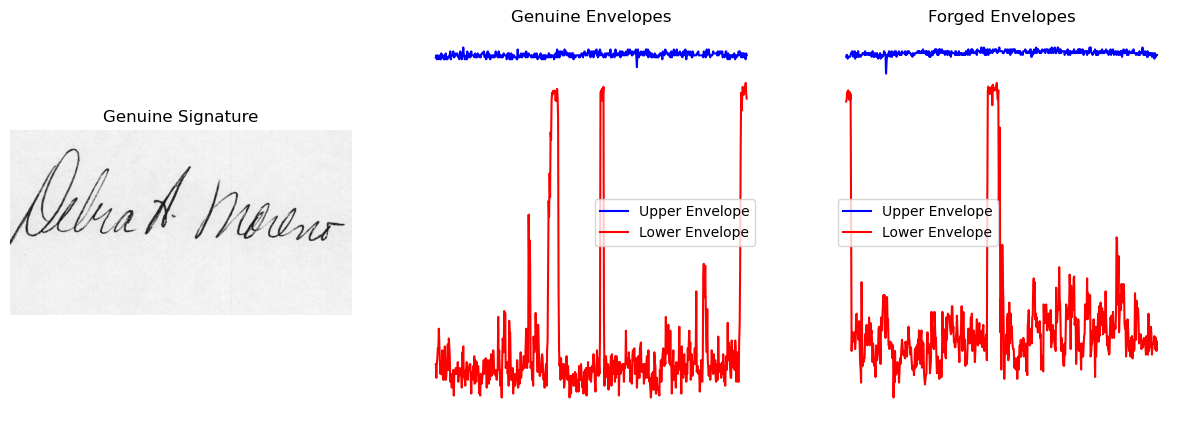

Statistical Features for Genuine Signature:
[[ 1.67572917e+02  7.84327623e+01  6.15169821e+03 -1.39171542e-01
  -1.94631965e+00]]

Statistical Features for Forged Signature:
[[ 1.79584906e+02  7.59669162e+01  5.77097235e+03 -1.38541855e-01
  -1.92867781e+00]]


In [70]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Function to calculate upper and lower envelopes of a signature
def calculate_envelopes(img):
    upper = np.max(img, axis=0)  # Max value along the columns
    lower = np.min(img, axis=0)  # Min value along the columns
    return upper, lower

# Function to extract statistical features from envelopes
def extract_statistical_features(images):
    features = []
    for img in images:
        # Calculate upper and lower envelopes
        upper, lower = calculate_envelopes(img)

        # Ensure envelopes are the same length
        min_len = min(len(upper), len(lower))  
        upper = upper[:min_len]
        lower = lower[:min_len]

        # Combine upper and lower envelopes
        envelopes = np.concatenate([upper, lower])

        # Extract statistical features
        mean = np.mean(envelopes)
        std = np.std(envelopes)
        var = np.var(envelopes)
        skewness = np.mean((envelopes - mean)**3) / (std**3 if std > 0 else 1)
        kurtosis = np.mean((envelopes - mean)**4) / (std**4 if std > 0 else 1) - 3

        # Add features as a vector
        features.append([mean, std, var, skewness, kurtosis])

    return np.array(features)

# Function to plot the original image and its envelopes for comparison
def plot_envelopes_comparison(genuine_img_path, forged_img_path):
    # Load the genuine and forged images in grayscale
    genuine_img = cv2.imread(genuine_img_path, cv2.IMREAD_GRAYSCALE)
    forged_img = cv2.imread(forged_img_path, cv2.IMREAD_GRAYSCALE)

    if genuine_img is None or forged_img is None:
        print(f"Error loading images.")
        return

    # Calculate the upper and lower envelopes for both images
    genuine_upper, genuine_lower = calculate_envelopes(genuine_img)
    forged_upper, forged_lower = calculate_envelopes(forged_img)

    # Ensure the envelopes are the same length
    min_len = min(len(genuine_upper), len(genuine_lower), len(forged_upper), len(forged_lower))
    genuine_upper = genuine_upper[:min_len]
    genuine_lower = genuine_lower[:min_len]
    forged_upper = forged_upper[:min_len]
    forged_lower = forged_lower[:min_len]

    # Plotting the results
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))

    # Plot the genuine image and its envelopes
    ax[0].imshow(genuine_img, cmap='gray')
    ax[0].set_title('Genuine Signature')
    ax[0].axis('off')

    # Plot the upper and lower envelopes for the genuine image
    ax[1].plot(genuine_upper, color='blue', label='Upper Envelope')
    ax[1].plot(genuine_lower, color='red', label='Lower Envelope')
    ax[1].set_title('Genuine Envelopes')
    ax[1].legend()
    ax[1].axis('off')

    # Plot the upper and lower envelopes for the forged image
    ax[2].plot(forged_upper, color='blue', label='Upper Envelope')
    ax[2].plot(forged_lower, color='red', label='Lower Envelope')
    ax[2].set_title('Forged Envelopes')
    ax[2].legend()
    ax[2].axis('off')

    plt.show()

# Example: Path to your signature images
genuine_img_path = "Downloads/FDS/signatures/full_org/original_9_3.png"  # Replace with your genuine image path
forged_img_path = "Downloads/FDS/signatures/full_org/original_48_11.png" # Replace with your forged image path

# Call the function to plot the images and their envelopes
plot_envelopes_comparison(genuine_img_path, forged_img_path)

# If you want to extract features and compare them statistically
genuine_image = cv2.imread(genuine_img_path, cv2.IMREAD_GRAYSCALE)
forged_image = cv2.imread(forged_img_path, cv2.IMREAD_GRAYSCALE)

# Extract features from the genuine and forged images
features_genuine = extract_statistical_features([genuine_image])
features_forged = extract_statistical_features([forged_image])

print("Statistical Features for Genuine Signature:")
print(features_genuine)

print("\nStatistical Features for Forged Signature:")
print(features_forged)


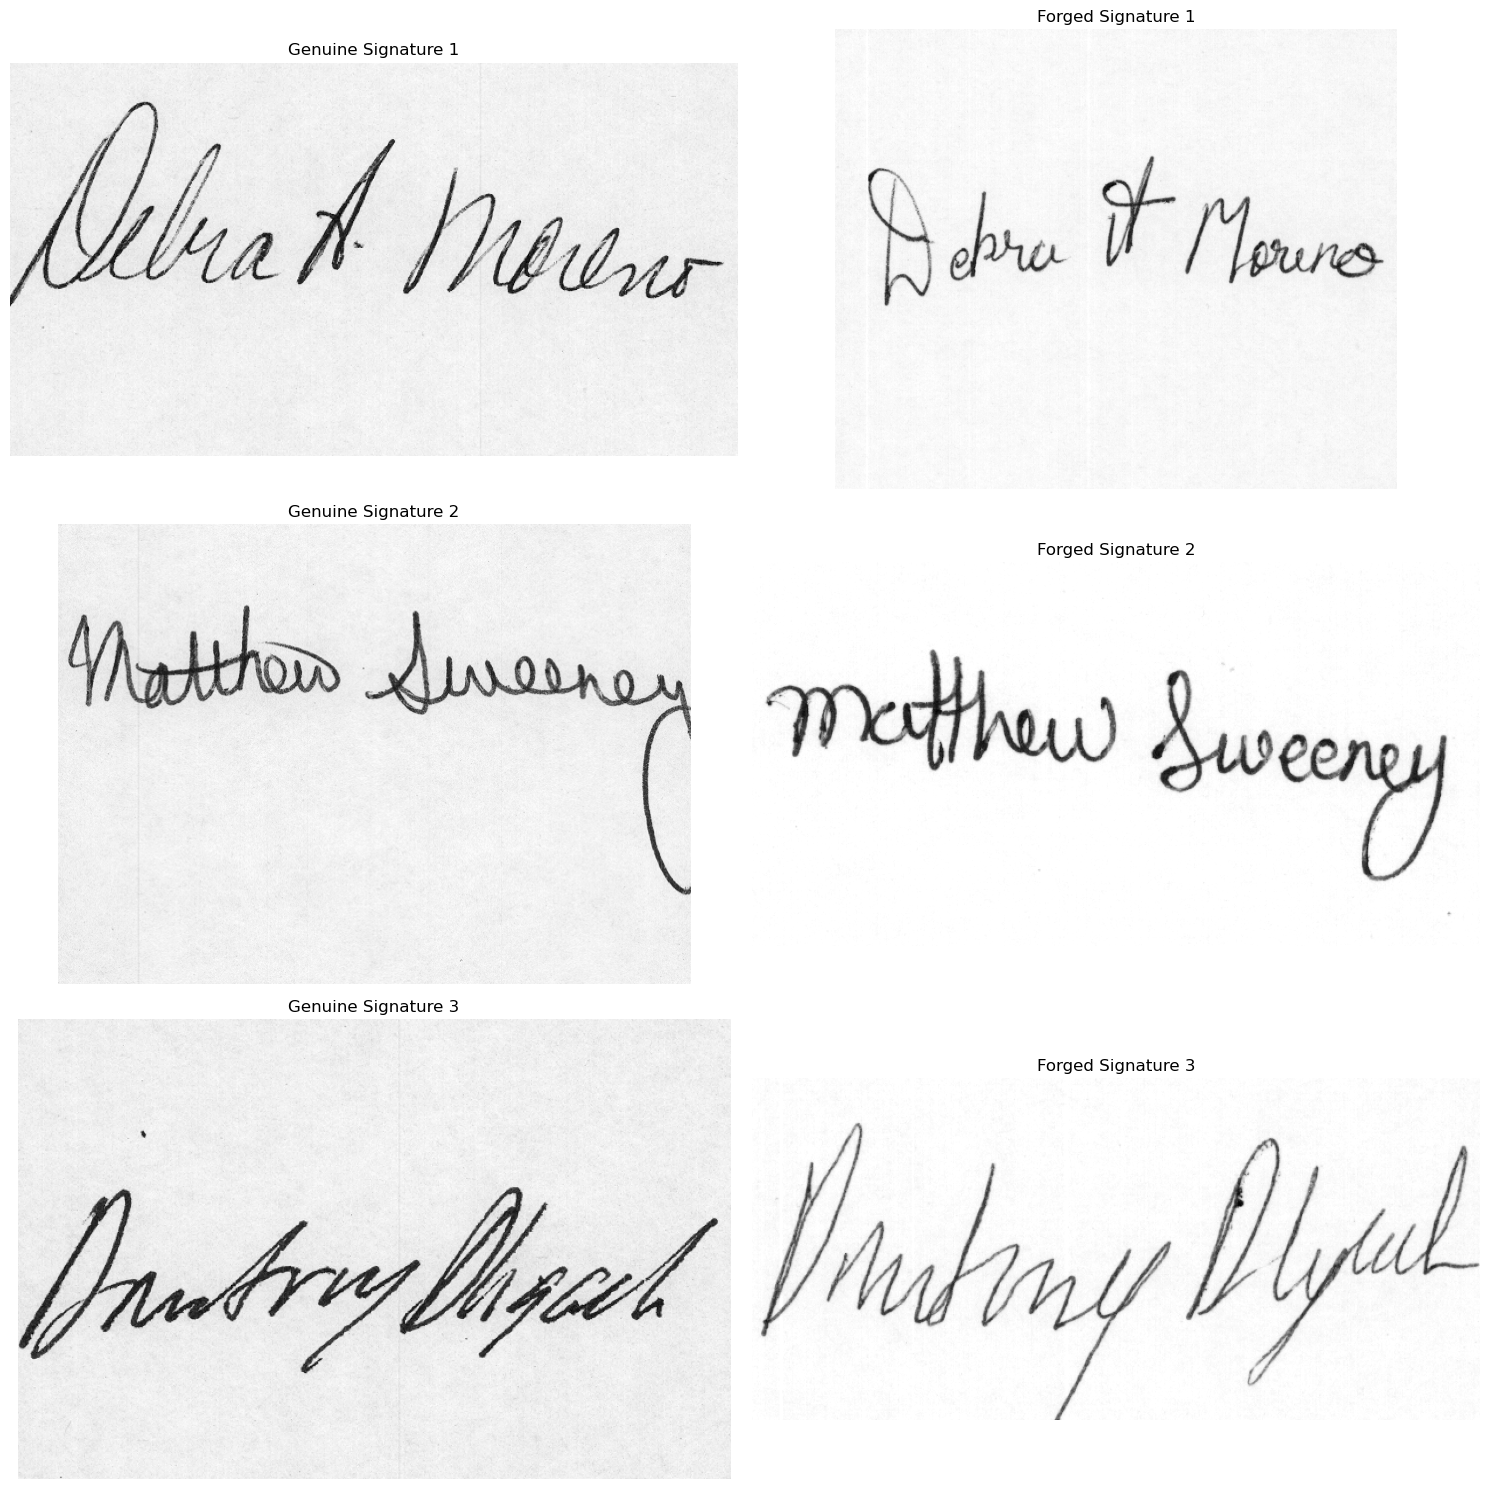

In [72]:
import cv2
import matplotlib.pyplot as plt

# Function to visualize multiple genuine vs forged images
def visualize_multiple_comparisons(genuine_image_paths, forged_image_paths):
    # Ensure both lists have the same length
    if len(genuine_image_paths) != len(forged_image_paths):
        print("Error: The number of genuine images and forged images must be the same!")
        return

    # Create a figure to display images
    num_images = len(genuine_image_paths)
    plt.figure(figsize=(15, 5 * num_images))  # Adjust the size based on the number of images

    for i in range(num_images):
        # Load images
        genuine_img = cv2.imread(genuine_image_paths[i], cv2.IMREAD_GRAYSCALE)
        forged_img = cv2.imread(forged_image_paths[i], cv2.IMREAD_GRAYSCALE)

        # Check if images are loaded successfully
        if genuine_img is None or forged_img is None:
            print(f"Error: Image {i+1} could not be loaded.")
            continue

        # Plot genuine and forged images side by side
        plt.subplot(num_images, 2, 2 * i + 1)  # Left side for genuine
        plt.imshow(genuine_img, cmap='gray')
        plt.title(f'Genuine Signature {i+1}')
        plt.axis('off')

        plt.subplot(num_images, 2, 2 * i + 2)  # Right side for forged
        plt.imshow(forged_img, cmap='gray')
        plt.title(f'Forged Signature {i+1}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Example: List of paths for genuine and forged images
genuine_image_paths = [
    "Downloads/FDS/signatures/full_org/original_9_3.png",  # Replace with your paths
    "Downloads/FDS/signatures/full_org/original_48_11.png",
    "Downloads/FDS/signatures/full_org/original_51_15.png"
]

# Fix the missing comma in the list of forged images
forged_image_paths = [
    "Downloads/FDS/signatures/full_forg/forgeries_9_3.png",  # Replace with your paths
    "Downloads/FDS/signatures/full_forg/forgeries_48_1.png",
    "Downloads/FDS/signatures/full_forg/forgeries_51_15.png"
]

# Call the function to compare multiple images
visualize_multiple_comparisons(genuine_image_paths, forged_image_paths)
